# NBT1 — Does the annotation actually work?

**Notebook revision: `2026-08-30-r1`**

You annotated **418** images by hand. A script replayed each derivative's
recorded transform onto those masks to produce the other **4,180**. This
notebook decides whether that replay was correct, in three passes that get
progressively harder to fool.

| | | Time |
|---|---|---|
| **A** | Coverage — does every image have a mask, the right size, with legal class values | ~1 min |
| **B** | Geometry — does each mask beat a deliberately corrupted copy of itself | ~3 min |
| **C** | The differential test — train on hand-drawn masks, score on propagated ones | ~20–35 min; record first Kaggle measurement |

### Why C is the one that counts

A and B can be satisfied by masks that are subtly wrong. C cannot.

Train a segmentation model **only on the 418 hand-drawn masks**, then score it
on two validation sets built from tyres it has never seen:

* the **hand-drawn** masks of those tyres
* the **propagated** masks of the derivatives of those same photos

The images in the second set are the same photographs, cropped and rotated. If
propagation is correct the model scores about the same on both. If propagation
is wrong the second score collapses — and it collapses *because of the labels*,
since the model never saw a propagated mask during training.

A **shuffled-label control** runs alongside, so you can see what a genuinely
broken annotation looks like in the same units instead of guessing.

---

> **This notebook found a real bug.** On its first run, propagated IoU came in
> far under clean IoU. The propagation script had been matching operations by
> substring and reading parameters under key names the dataset does not use
> (`box` instead of `crop_box`, `angle` instead of `degrees`), so the crop and
> the rotation were silently skipped on all 4,180 files — which were written
> anyway, correctly sized, with legal class values, looking entirely normal.

> **It then failed twice more for a reason that was not its fault.** Kaggle
> pins **one version** of a dataset to a notebook; re-uploading does not move
> existing notebooks onto the new one. The fixed masks existed on disk and the
> notebook kept reading the old copy, silently.
>
> So it no longer reads them. **It rebuilds them** — see the next section. The
> version of the dataset you have attached does not matter any more.

---

## Running it

1. **Add Input** → your `Tire Dataset Prepared` dataset. **Any version.**
2. **Add-ons → Secrets** → `HF_TOKEN`
3. **Accelerator:** GPU T4 ×2 · **Internet:** ON
4. Run All. Stop whenever you like — Part C checkpoints every epoch and
   also checkpoints inside long epochs, then resumes from HuggingFace.

This revision also uses both T4s, writes checkpoints atomically, pushes on a
real 30-minute background timer, saves before SIGTERM / Ctrl-C exits, and keeps
the diagnostic overlays when a geometry gate fails.


## Setup

In [1]:
# === Unpack tyrelib =======================================================
# Embedded, not downloaded: this notebook must run before anything has been
# pushed anywhere, and with no assumption about what the study repo contains.
#
# Only `ensure_annotations` is used from it -- to BUILD correct masks. The
# tests that judge those masks are written out longhand below and share no
# code with the propagation, so this notebook can still fail the library.
import base64, sys, subprocess
from pathlib import Path

WORK = Path('/kaggle/working') if Path('/kaggle/working').is_dir() else Path.cwd()

_LIB = (
    '...',
    'Y29yZXMsIGR4PTEuMCAvIHN0ZXBzKSkK',
)

(WORK / 'tyrelib.py').write_bytes(base64.b64decode(''.join(_LIB)))
if str(WORK) not in sys.path:
    sys.path.insert(0, str(WORK))
for _m in [m for m in list(sys.modules) if m == 'tyrelib']:
    del sys.modules[_m]
import tyrelib as tl
print('tyrelib', tl.__version__, 'loaded')


tyrelib v2 loaded


In [2]:
# === Setup ================================================================
import os, sys, json, math, time, random, signal, atexit, threading, contextlib, hashlib
import numpy as np, pandas as pd
from pathlib import Path
from PIL import Image

NBT1_REVISION = '2026-08-30-r1'
print('NBT1 revision', NBT1_REVISION)

for _p in ('pyarrow',):
    try: __import__(_p)
    except ImportError:
        import subprocess; subprocess.run([sys.executable,'-m','pip','install','-q',_p], check=False)

SEED = 1
random.seed(SEED); np.random.seed(SEED)

# ---- where things are ----------------------------------------------------
def find_final(hint=None):
    """Kaggle sometimes wraps an uploaded folder in an extra directory."""
    for base in ([Path(hint)] if hint else []) + [Path('/kaggle/input'), Path.cwd()]:
        if not base.exists(): continue
        if (base/'images').is_dir() and (base/'splits').is_dir(): return base
        for p in sorted(base.rglob('*')):
            if p.is_dir() and (p/'images').is_dir() and (p/'splits').is_dir() and (p/'manifests').is_dir():
                return p
    return None

def find_ann(final):
    for c in [Path(final).parent/'annotations', Path(final)/'annotations', Path('/kaggle/input')]:
        if c.name == 'annotations' and (c/'clean'/'masks').is_dir(): return c
        if c.exists():
            for p in sorted(c.rglob('annotations')):
                if p.is_dir() and (p/'clean'/'masks').is_dir(): return p
    return None

FINAL = find_final()
assert FINAL, 'dataset not found -- Add Input -> your Tire Dataset Prepared dataset'
ANN = find_ann(FINAL)
assert ANN, 'annotations/ not found -- it must sit beside FINAL/ in the same dataset'
print('FINAL      ', FINAL)
print('annotations', ANN)

# /kaggle/working is capped at 20 GB and that cap is your OUTPUT size, not your
# scratch. /kaggle/temp is on the big disk. Create it rather than test for it.
import shutil
STAGE = None
for cand in ('/kaggle/temp', '/tmp', '.'):
    try:
        p = Path(cand)/'nbt1'; p.mkdir(parents=True, exist_ok=True)
        (p/'.w').write_text('ok'); (p/'.w').unlink(); STAGE = p; break
    except Exception: continue
if STAGE is None:
    raise RuntimeError('no writable scratch directory found; expected /kaggle/temp or /tmp')
print('staging    ', STAGE, f'({shutil.disk_usage(STAGE).free/1e9:.0f} GB free)')



NBT1 revision 2026-08-30-r1
FINAL       /kaggle/input/datasets/shanmuk4622/tire-dataset-prepared/Tire Dataset Prepared/FINAL
annotations /kaggle/input/datasets/shanmuk4622/tire-dataset-prepared/Tire Dataset Prepared/annotations
staging     /kaggle/temp/nbt1 (1103 GB free)


In [3]:
# === HuggingFace: push on a timer, on every phase, and on stop ============
# The rule for this project is that nothing exists until it is on HuggingFace.
# This uploader keeps one pending copy per repo path, serialises commits, retries
# transient/429 failures, and owns a REAL timer thread. A long epoch therefore
# cannot postpone the 30-minute push until it happens to finish.
import re
from collections import deque

HF_REPO   = 'Shanmuk4622/tyre-wear-study'
HF_PREFIX = 'annotation_test/2026-08-30-r1'
# Revision-specific prefix: preserve the earlier failed/stale-data attempt and
# never let its legacy FP16 checkpoint skip this repaired verification run.

HF_TOKEN = None
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret('HF_TOKEN')
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN')

class Push:
    def __init__(self, repo, token, prefix, interval_min=30, write_limit_per_hour=100):
        self.repo, self.token, self.prefix = repo, token, prefix
        self.interval = interval_min*60
        self.write_limit = int(write_limit_per_hour)   # 28 operations/hour headroom below HF's ~128
        self.buf, self.lock = {}, threading.Lock()
        self.flush_lock, self.rate_lock = threading.Lock(), threading.Lock()
        self.calls, self.stop_event = deque(), threading.Event()
        self.timer_thread = None
        self.api = None; self.commits = 0; self.last = time.time()
        self.on = bool(token)
        if self.on:
            try:
                from huggingface_hub import HfApi
                self.api = HfApi(token=token)
                self.api.create_repo(repo, repo_type='dataset', exist_ok=True, private=True)
                print('[HF] authenticated as', self.api.whoami().get('name','?'), '->', repo)
            except Exception as e:
                print('[HF] DISABLED --', type(e).__name__, e); self.on = False
        else:
            print('[HF] DISABLED -- no HF_TOKEN secret; results stay in this session only')

        if self.on:
            self.timer_thread = threading.Thread(target=self._timer_loop,
                                                 name='nbt1-hf-timer', daemon=True)
            self.timer_thread.start()
            print(f'[HF] timer active: {interval_min} min; write cap {self.write_limit}/hour')

    def add(self, local, rel):
        p = Path(local)
        if p.exists():
            with self.lock: self.buf[f'{self.prefix}/{rel}'] = str(p)

    def _timer_loop(self):
        while not self.stop_event.wait(self.interval):
            self.flush('30-minute timer')

    def _rate_slot(self):
        while True:
            t = time.time()
            with self.rate_lock:
                while self.calls and t-self.calls[0] >= 3600:
                    self.calls.popleft()
                if len(self.calls) < self.write_limit:
                    self.calls.append(t)
                    return
                wait = max(1.0, 3602-(t-self.calls[0]))
            print(f'[HF] local write budget spent; waiting {wait:.0f}s')
            self.stop_event.wait(min(wait, 60))

    @staticmethod
    def _retry_after(err, attempt):
        s = str(err)
        m = re.search(r'retry after\s*(\d+)\s*second', s, re.I)
        if m: return float(m.group(1)) + 2
        m = re.search(r'in about\s*(\d+)\s*minute', s, re.I)
        if m: return float(m.group(1))*60 + 5
        return min(300.0, 5.0*(2**attempt))

    def flush(self, reason=''):
        if not self.on: return False
        with self.flush_lock:                 # timer and manual pushes cannot race
            with self.lock:
                batch = dict(self.buf); self.buf.clear()
            if not batch: return True

            from huggingface_hub import CommitOperationAdd
            ops = [CommitOperationAdd(path_in_repo=k, path_or_fileobj=v)
                   for k, v in batch.items() if Path(v).exists()]
            if not ops: return True
            last_error = None
            for attempt in range(5):
                try:
                    self._rate_slot()
                    self.api.create_commit(self.repo, ops, repo_type='dataset',
                                           commit_message=f'NBT1: {reason}'[:100])
                    self.commits += 1; self.last = time.time()
                    print(f'[HF] pushed {len(ops)} file(s)  ({reason})')
                    return True
                except Exception as e:
                    last_error = e; msg = str(e).lower()
                    if '401' in msg or '403' in msg or 'unauthorized' in msg or 'forbidden' in msg:
                        print('[HF] authentication failed; uploader disabled:', e)
                        self.on = False
                        break
                    wait = self._retry_after(e, attempt)
                    print(f'[HF] push attempt {attempt+1}/5 failed -- {type(e).__name__}: {e}')
                    if attempt < 4:
                        print(f'[HF] retrying in {wait:.0f}s')
                        self.stop_event.wait(wait)
            print('[HF] push failed -- files returned to buffer:', last_error)
            with self.lock:
                for k, v in batch.items(): self.buf.setdefault(k, v)
            return False

    def maybe(self, reason=''):
        if time.time() - self.last >= self.interval: self.flush(reason or 'interval')

    def get(self, rel, dest):
        """Pull a file back. This is what makes a restart resume rather than redo."""
        if not self.on: return False
        try:
            from huggingface_hub import hf_hub_download
            files = set(self.api.list_repo_files(self.repo, repo_type='dataset'))
            rp = f'{self.prefix}/{rel}'
            if rp not in files: return False
            src = hf_hub_download(self.repo, rp, repo_type='dataset', token=self.token)
            Path(dest).parent.mkdir(parents=True, exist_ok=True)
            shutil.copy(src, dest); return True
        except Exception as e:
            print('[HF] fetch failed --', type(e).__name__, e); return False

    def close(self):
        self.stop_event.set()
        if self.timer_thread and self.timer_thread is not threading.current_thread():
            self.timer_thread.join(timeout=2)

# Re-running this setup cell must not leave the previous timer thread alive.
if 'PUSH' in globals():
    with contextlib.suppress(Exception): PUSH.close()
PUSH = Push(HF_REPO, HF_TOKEN, HF_PREFIX)

_fired = threading.Event()
_emergency_saver = None
def register_emergency_saver(fn):
    global _emergency_saver
    _emergency_saver = fn

def _emergency(reason):
    if _fired.is_set(): return
    _fired.set(); print(f'\n[LIFE] checkpoint + flush triggered by {reason}')
    if callable(_emergency_saver):
        try: _emergency_saver(reason)
        except Exception as e: print('[LIFE] emergency checkpoint failed --', type(e).__name__, e)
    PUSH.flush(reason)
def _sig(signum, frame):
    _emergency(f'signal {signum}')
    if signum == signal.SIGINT: raise KeyboardInterrupt
    raise SystemExit(128 + int(signum))
for _s in (signal.SIGTERM, signal.SIGINT):
    with contextlib.suppress(Exception): signal.signal(_s, _sig)
def _at_exit():
    _emergency('atexit'); PUSH.close()
atexit.register(_at_exit)
print('[LIFE] guards installed (SIGTERM, SIGINT, atexit)')

RESULTS = {}
def save_results(reason):
    p = STAGE/'results.json'
    p.write_text(json.dumps(RESULTS, indent=2, default=str))
    PUSH.add(p, 'results.json'); PUSH.flush(reason)


[HF] authenticated as Shanmuk4622 -> Shanmuk4622/tyre-wear-study
[HF] timer active: 30 min; write cap 100/hour
[LIFE] guards installed (SIGTERM, SIGINT, atexit)


## Repair the masks first, then test them

This notebook no longer cares which version of the dataset Kaggle attached.

Kaggle pins **one version** of a dataset to a notebook, and re-uploading does
not move existing notebooks onto the new one — they keep reading the old copy
silently, with nothing on screen to say so. That is unfixable from inside a
notebook, and it cost two full runs of this one.

But it never had to matter. Everything needed to *build* the propagated masks
is in **every** version of the dataset:

| | |
|---|---|
| `annotations/clean/masks/` | the 418 hand-drawn masks — these were never broken |
| `FINAL/manifests/dataset_manifest.csv` | `augmentation_trace_json` — the exact operations, in order, for all 4,180 derivatives |

So `ensure_annotations()`:

1. **Measures** the propagated masks that are present — 3 seconds, against
   shifted / mirrored / swapped copies of themselves.
2. Uses them if they track their images.
3. Otherwise **rebuilds all 4,180 from the clean masks and the traces**, into
   the session scratch directory — 20 seconds — measures again, and uses those.
4. Fails only if the *rebuilt* masks are also bad, which would mean the
   hand-drawn masks or the traces are wrong. That is a real problem; a stale
   upload is not.

**Nothing is gated on `ANNOTATION_VERSION.json`.** A label is not evidence: it
can read `v2` over broken masks — which is exactly the case that a version
check waves through and a measurement catches.

In [4]:
# === Get masks that are known to be correct ==============================
# tyrelib is embedded in the cell above -- no network, and the propagation
# logic here is byte-identical to the one the training notebooks use.
ANN_DIRS = tl.ensure_annotations(FINAL, ann_root=ANN, work_dir=STAGE/'annotations')

CLEAN_MASKS = Path(ANN_DIRS['clean_masks'])
PROP_MASKS  = Path(ANN_DIRS['propagated_masks'])
print()
print('=' * 68)
print(f'  clean masks       {CLEAN_MASKS}')
print(f'  propagated masks  {PROP_MASKS}')
print(f'  rebuilt this run  {ANN_DIRS.get("rebuilt")}')
print('=' * 68)

def mask_path(image_id, kind):
    """Every mask read in this notebook goes through here, so Parts A, B and C
    are guaranteed to be looking at the same masks ensure_annotations blessed."""
    return (CLEAN_MASKS if kind == 'clean_original' else PROP_MASKS) / f'{image_id}.png'

def annotation_fingerprint():
    """Short, deterministic identity for the exact masks this run consumes.

    Hash a spread across both directories rather than trusting a version label.
    This is recorded in every checkpoint, result file, and the console output.
    """
    h = hashlib.sha256()
    for label, folder in (('clean', CLEAN_MASKS), ('propagated', PROP_MASKS)):
        files = sorted(folder.glob('*.png'))
        if not files: continue
        # first/middle/last samples catch a stale or partially rebuilt directory
        idx = sorted(set(np.linspace(0, len(files)-1, min(32, len(files)), dtype=int).tolist()))
        h.update(f'{label}:{len(files)}'.encode())
        for i in idx:
            p = files[i]; h.update(p.name.encode()); h.update(p.read_bytes())
    return h.hexdigest()[:16]

ANN_FINGERPRINT = annotation_fingerprint()
try:
    v = json.loads((ANN/'ANNOTATION_VERSION.json').read_text()) if (ANN/'ANNOTATION_VERSION.json').exists() else {}
except Exception as e:
    print('ANNOTATION_VERSION.json unreadable -- recorded as unknown:', type(e).__name__, e)
    v = {}
ANN_VERSION = v.get('annotation_version', 'unknown')
print(f"\nANNOTATION_VERSION.json says {ANN_VERSION!r} -- recorded, not trusted, not used.")
print('masks actually used fingerprint:', ANN_FINGERPRINT)
RESULTS['notebook_revision'] = NBT1_REVISION
RESULTS['annotation_version_label'] = ANN_VERSION
RESULTS['annotation_fingerprint'] = ANN_FINGERPRINT


[ANN] root /kaggle/input/datasets/shanmuk4622/tire-dataset-prepared/Tire Dataset Prepared/annotations  (file says version 'v1' -- not trusted, measuring)
[ANN] as supplied: correct 17.1  worst control 18.0  margin -0.8  -> MISALIGNED
[ANN] rebuilding from the 418 hand-drawn masks + the recorded transform traces (both are in every version of the dataset)
    1000/4180
    2000/4180
    3000/4180
    4000/4180
[ANN] rebuilt 4180 propagated mask(s) in 34s
[ANN] rebuilt:     correct 35.3  worst control 21.4  margin +13.9  -> OK
[ANN] using rebuilt masks at /kaggle/temp/nbt1/annotations/propagated/masks

  clean masks       /kaggle/input/datasets/shanmuk4622/tire-dataset-prepared/Tire Dataset Prepared/annotations/clean/masks
  propagated masks  /kaggle/temp/nbt1/annotations/propagated/masks
  rebuilt this run  True

ANNOTATION_VERSION.json says 'v1' -- recorded, not trusted, not used.
masks actually used fingerprint: 085acfb8fb83c531


## Part A — Coverage

The cheapest question: does every image have a mask at all, at the right size,
with only legal class values in it? This cannot tell you a mask is *correct*,
only that it exists and is well-formed. Part B and C do the rest.

Class encoding: `0` background · `1` tyre · `2` tread · `3` marking · `4` damage.
The mask is a single indexed layer, so a later class **erases** the one under
it — `m == 1` is not "the tyre", it is "tyre minus whatever is painted on top".
On a head-on tyre photo that is nearly empty. Use `m > 0`.

In [5]:
# === Part A: coverage =====================================================
man = pd.read_csv(FINAL/'manifests'/'dataset_manifest.csv', encoding='utf-8-sig')
man.columns = [c.lstrip('﻿') for c in man.columns]
clean = man[man.image_kind == 'clean_original'].reset_index(drop=True)
aug   = man[man.image_kind == 'synthetic_derivative'].reset_index(drop=True)
print(f'{len(clean)} clean images, {len(aug)} derivatives, {len(man)} total')

# mask_path() comes from the repair cell -- every mask read in this notebook
# goes through it, so Parts A, B and C cannot end up looking at different
# masks from each other.

rows = []
for kind, sub in (('clean_original', clean), ('synthetic_derivative', aug)):
    missing = [r.image_id for r in sub.itertuples() if not mask_path(r.image_id, kind).exists()]
    rows.append({'kind': kind, 'images': len(sub), 'masks_present': len(sub)-len(missing),
                 'missing': len(missing)})
cov = pd.DataFrame(rows)
print(); print(cov.to_string(index=False))

# Well-formedness on ALL masks. A sample is not enough for a notebook whose
# verdict says all 4,598 images are usable.
bad_size, bad_vals, empty = [], [], []
for r in man.itertuples():
    p = mask_path(r.image_id, r.image_kind)
    if not p.exists(): continue
    with Image.open(p) as _mk: m = np.asarray(_mk)
    with Image.open(FINAL/r.relative_path) as im: image_size = im.size
    if m.shape != (image_size[1], image_size[0]): bad_size.append(r.image_id)
    if not set(np.unique(m).tolist()) <= {0,1,2,3,4}: bad_vals.append(r.image_id)
    if (m > 0).mean() < 0.02: empty.append(r.image_id)

print(f'\nchecked all {len(man)} masks:  size mismatch {len(bad_size)}   '
      f'illegal class value {len(bad_vals)}   effectively empty {len(empty)}')
expected_counts = len(clean) == 418 and len(aug) == 4180 and len(man) == 4598
unique_ids = man.image_id.nunique() == len(man)
sources_resolve = set(aug.source_image_id.astype(str)) <= set(clean.image_id.astype(str))
A_OK = (expected_counts and unique_ids and sources_resolve and
        cov.missing.sum() == 0 and not bad_size and not bad_vals and not empty)
print('\nPART A:', 'PASS -- every image has a well-formed mask' if A_OK
      else 'FAIL -- see the counts above')
RESULTS['part_a'] = {'ok': bool(A_OK), 'coverage': cov.to_dict('records'),
                     'expected_counts': bool(expected_counts), 'unique_ids': bool(unique_ids),
                     'sources_resolve': bool(sources_resolve),
                     'bad_size': len(bad_size), 'bad_vals': len(bad_vals), 'empty': len(empty)}
save_results('part A complete')
if not A_OK:
    raise RuntimeError(
        'Part A failed. Expected 418 clean + 4,180 derivatives, unique image IDs, '
        'valid source links, and one legal non-empty mask of the correct size per image. '
        'Fix the counts above before running the geometry or training tests.')


418 clean images, 4180 derivatives, 4598 total

                kind  images  masks_present  missing
      clean_original     418            418        0
synthetic_derivative    4180           4180        0

checked all 4598 masks:  size mismatch 0   illegal class value 0   effectively empty 0

PART A: PASS -- every image has a well-formed mask
[HF] pushed 1 file(s)  (part A complete)


## Part B — Geometry, without training anything

A tyre is much darker than road, wall and sky. So a correctly placed mask puts
the dark pixels inside it and the bright ones outside, and

    alignment  =  mean luminance OUTSIDE  −  mean luminance INSIDE

is large. Misplace the mask and the two populations mix and it collapses. The
measure needs no ground truth beyond the image itself, which is exactly why it
can catch a replay bug that produced perfectly well-formed files.

The absolute number means nothing on its own — a brightness-augmented crop
scores lower than its clean parent for reasons that have nothing to do with
geometry. So each mask is scored against three corrupted copies of **itself**,
on the **same** image, with the **same** photometry. Only the placement differs:

| control | what it detects |
|---|---|
| shifted 6% sideways | translation error — a dropped or mis-sized crop |
| mirrored | a flip applied in the wrong order, or not at all |
| swapped with another image's mask | the replay is not tracking the image at all |

The broken v1 masks scored 16.1 against a swap control of 9.8. Barely better
than a mask belonging to a different photograph.

In [6]:
# === Part B: geometry, no training ========================================
def alignment(grey, mask):
    t = mask > 0; f = t.mean()
    if f < 0.02 or f > 0.995: return np.nan
    return float(grey[~t].mean() - grey[t].mean())

def ops_of(j):
    try: return [o['name'] for o in json.loads(j)['operations']]
    except Exception: return []

aug = aug.copy()
aug['ops']  = aug.augmentation_trace_json.map(ops_of)
aug['flip'] = aug.ops.map(lambda o: 'horizontal_flip' in o)
aug['rot']  = aug.ops.map(lambda o: 'rotation' in o)

def score_group(sub, n=200, seed=0):
    rows = list(sub.itertuples()); random.Random(seed).shuffle(rows)
    cor, shf, mir, swp = [], [], [], []
    prev = None
    for r in rows:
        p = mask_path(r.image_id, 'synthetic_derivative'); ip = FINAL/r.relative_path
        if not (p.exists() and ip.exists()): continue
        g = np.asarray(Image.open(ip).convert('L'), dtype=np.float32)
        k = np.asarray(Image.open(p))
        if g.shape != k.shape: continue
        d = int(0.06*k.shape[1])
        cor.append(alignment(g, k))
        shf.append(alignment(g, np.roll(k, d, axis=1)))
        mir.append(alignment(g, k[:, ::-1]))
        if prev is not None and prev.shape == k.shape: swp.append(alignment(g, prev))
        prev = k
        if len(cor) >= n: break
    f = lambda x: float(np.nanmean(x)) if len(x) else float('nan')
    return dict(n=len(cor), correct=f(cor), shifted=f(shf), mirrored=f(mir), swapped=f(swp))

groups = {'all derivatives': aug,
          'flipped':         aug[aug.flip],
          'not flipped':     aug[~aug.flip],
          'rotated':         aug[aug.rot]}
tab = pd.DataFrame({k: score_group(v) for k, v in groups.items()}).T
tab['worst control'] = tab[['shifted','mirrored','swapped']].max(axis=1)
tab['margin'] = tab.correct - tab['worst control']
print(tab.round(2).to_string())

tested = tab[tab.n >= 20]
skipped_groups = sorted(set(tab.index) - set(tested.index))
B_OK = bool('all derivatives' in tested.index and (tested.margin > 5.0).all())
print('\nPART B:', 'PASS -- every corruption scores clearly worse than the real mask'
      if B_OK else 'FAIL -- masks barely beat a deliberately wrong mask')
if skipped_groups:
    print('groups skipped because fewer than 20 examples exist:', ', '.join(skipped_groups))
print('\nA margin below +5 in the "flipped" row alone means the flip is applied in the')
print('wrong order. A low margin everywhere means the crop or the resize is wrong.')
RESULTS['part_b'] = {'ok': B_OK, 'tested_groups': list(tested.index),
                     'skipped_groups': skipped_groups,
                     'table': tab.round(3).to_dict('index')}
save_results('part B complete')

if not B_OK:
    print('\nPart B failed. The next cell will still save diagnostic overlays,')
    print('then it will stop before the longer FP32 training test.')


                     n  correct  shifted  mirrored  swapped  worst control  margin
all derivatives  200.0    32.89    19.30     12.37    13.45          19.30   13.59
flipped          200.0    30.71    18.51      8.02    13.09          18.51   12.21
not flipped      200.0    34.12    19.82     14.59    16.87          19.82   14.31
rotated          200.0    32.65    18.62     14.55    14.86          18.62   14.03

PART B: PASS -- every corruption scores clearly worse than the real mask

A margin below +5 in the "flipped" row alone means the flip is applied in the
wrong order. A low margin everywhere means the crop or the resize is wrong.
[HF] pushed 1 file(s)  (part B complete)


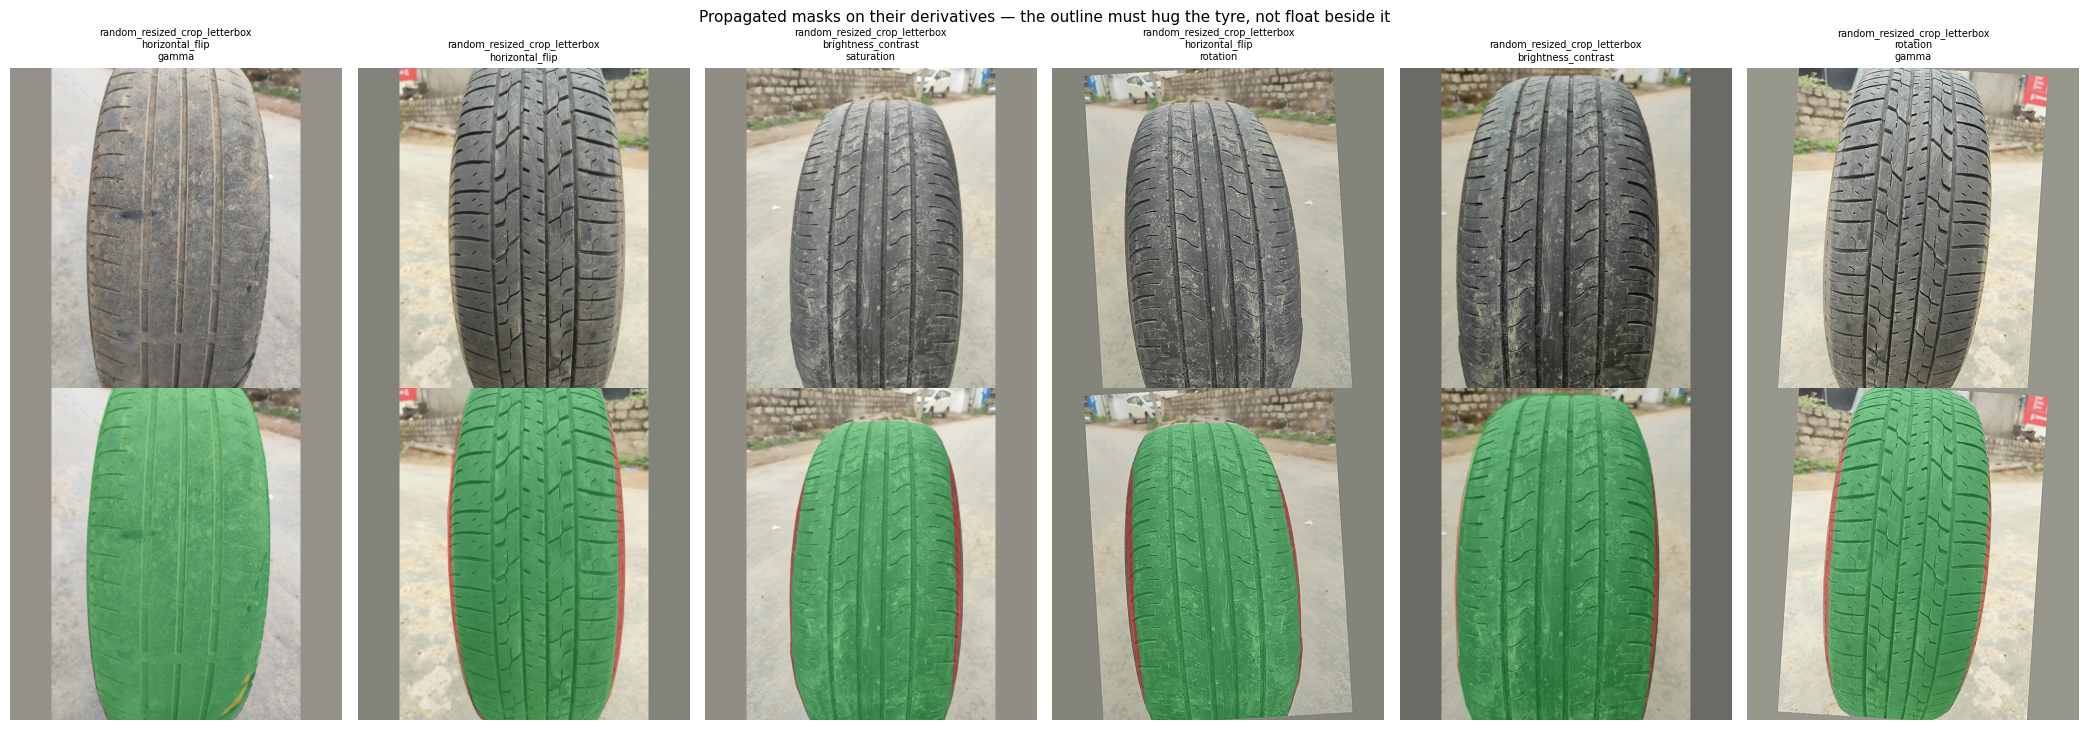

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[HF] pushed 1 file(s)  (part B overlays)


In [7]:
# === Part B: look at them ================================================
# The numbers catch gross misalignment; your eyes catch the subtle kind. Do not
# skip this cell -- a mask can be 4 pixels off everywhere and still pass above.
import matplotlib.pyplot as plt
COLOURS = np.array([[0,0,0],[220,40,40],[40,200,80],[60,110,240],[240,210,50]], np.uint8)

pick = aug.sample(6, random_state=3)
fig, axes = plt.subplots(2, 6, figsize=(21, 7.4))
for j, r in enumerate(pick.itertuples()):
    im = np.asarray(Image.open(FINAL/r.relative_path).convert('RGB'))
    m  = np.asarray(Image.open(mask_path(r.image_id, 'synthetic_derivative')))
    ov = (im*(1-0.45*(m>0)[...,None]) + COLOURS[np.clip(m,0,4)]*0.45*(m>0)[...,None]).astype(np.uint8)
    axes[0, j].imshow(im); axes[0, j].set_title('\n'.join(r.ops[:3]), fontsize=7)
    axes[1, j].imshow(ov)
    for a in (axes[0, j], axes[1, j]): a.axis('off')
axes[0,0].set_ylabel('image'); axes[1,0].set_ylabel('mask')
plt.suptitle('Propagated masks on their derivatives — the outline must hug the tyre, '
             'not float beside it', fontsize=11)
plt.tight_layout()
p = STAGE/'partB_overlays.png'; plt.savefig(p, dpi=95, bbox_inches='tight'); plt.show()
PUSH.add(p, 'partB_overlays.png'); PUSH.flush('part B overlays')

# Stop only AFTER preserving the evidence. Previously the gate was in the
# preceding cell, so Run All stopped before the one figure needed to diagnose it.
if not B_OK:
    raise RuntimeError(f"""
Part B failed, so Part C was not run.

Your numbers        correct {tab.loc['all derivatives','correct']:.1f}
                    worst control {tab.loc['all derivatives','worst control']:.1f}
                    margin {tab.loc['all derivatives','margin']:+.1f}

ensure_annotations() already measured the supplied masks and rebuilt them when
needed. Reaching this point means the independent grouped test still rejects
the masks. Inspect partB_overlays.png on screen and on HuggingFace.

Likely causes:
  * one or more of the 418 hand-drawn masks is wrong, or
  * augmentation_trace_json contains an operation/order the replay does not match.

masks rebuilt this run: {ANN_DIRS.get('rebuilt')}
propagated masks used:  {PROP_MASKS}
fingerprint:            {ANN_FINGERPRINT}
""")


## Part C — The differential test

Train a small U-Net on the **418 hand-drawn masks only**, holding out whole
tyres. Then score it three ways on tyres it has never seen:

| scored against | what it tells you |
|---|---|
| **hand-drawn** masks of held-out tyres | how good the model is — the reference |
| **propagated** masks of derivatives of those same photos | how good the propagation is |
| **shuffled** propagated masks | the floor: what a broken annotation scores |

The model never sees a propagated mask while training, so the second number is
not measuring the model. Both validation sets contain the same tyres in the
same photographs; the derivatives are merely cropped and rotated. So if the
first two numbers agree, the replay put the masks in the right place. If the
second collapses toward the third, it did not.

**Also report the trivial floor**: the tyre fills roughly 70% of the frame, so
"predict tyre everywhere" already scores about 0.70 IoU. A number is only
meaningful above that.

In [8]:
# === Part C: data =========================================================
# Everything is pre-decoded to 256x256 and held in RAM. 418 clean + ~900
# derivatives is well under a gigabyte, and it turns a JPEG-bound training loop
# into a GPU-bound one.
import torch, torch.nn as nn, torch.nn.functional as Fn
from torch.utils.data import Dataset, DataLoader
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

RES, FOLD = 256, 0
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU_COUNT = torch.cuda.device_count() if dev.type == 'cuda' else 0
print('device', dev, '| GPUs', GPU_COUNT)
for i in range(GPU_COUNT):
    print(f'  gpu{i}:', torch.cuda.get_device_name(i))
if GPU_COUNT == 1:
    print('WARNING: one GPU is visible. Select Kaggle GPU T4 x2 to use the intended configuration.')

val_ids   = set(pd.read_csv(FINAL/f'splits/cv{FOLD}_validation.csv', encoding='utf-8-sig').image_id)
clean_tr  = clean[~clean.image_id.isin(val_ids)]
clean_va  = clean[ clean.image_id.isin(val_ids)]
prop_va   = aug[aug.source_image_id.isin(set(clean_va.image_id))]
print(f'train  {len(clean_tr):4d} hand-drawn')
print(f'val A  {len(clean_va):4d} hand-drawn, held-out tyres')
print(f'val B  {len(prop_va):4d} propagated, derivatives of the SAME photos')
assert set(clean_tr.session_group) & set(clean_va.session_group) == set(), 'session leak between train and val'
print('no session appears in both train and val')

def load_one(args):
    rel, mp = args
    im = Image.open(FINAL/rel).convert('RGB').resize((RES,RES), Image.BILINEAR)
    mk = Image.open(mp).resize((RES,RES), Image.NEAREST)     # NEAREST: bilinear invents classes
    return np.asarray(im, np.uint8), np.asarray(mk, np.uint8)

def preload(sub, kind, label):
    jobs = [(r.relative_path, mask_path(r.image_id, kind)) for r in sub.itertuples()]
    t0 = time.time()
    with ThreadPoolExecutor(8) as ex: out = list(ex.map(load_one, jobs))
    X = np.stack([o[0] for o in out]); Y = np.stack([o[1] for o in out])
    print(f'  {label:24s} {X.shape}  {time.time()-t0:.0f}s')
    return X, Y

print('\npreloading at', RES, 'px:')
Xtr, Ytr = preload(clean_tr, 'clean_original',        'train (hand-drawn)')
Xva, Yva = preload(clean_va, 'clean_original',        'val A (hand-drawn)')
Xpr, Ypr = preload(prop_va,  'synthetic_derivative',  'val B (propagated)')

# The floor: how well does "everything is tyre" do?
TRIVIAL = float((Yva > 0).mean())
print(f'\ntyre occupies {TRIVIAL:.1%} of the frame -- '
      f'"predict tyre everywhere" already scores IoU {TRIVIAL:.3f}')

MEAN = np.array([0.485,0.456,0.406], np.float32); STD = np.array([0.229,0.224,0.225], np.float32)

class SegSet(Dataset):
    """Binary foreground: tyre (any annotated class) vs background.
    Uses m > 0, never m == 1 -- the mask is one indexed layer and tread erases
    tyre underneath it."""
    def __init__(self, X, Y, train=False):
        self.X, self.Y, self.train, self.epoch = X, Y, train, 0
    def set_epoch(self, epoch): self.epoch = int(epoch)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x, y = self.X[i], (self.Y[i] > 0).astype(np.float32)
        # Deterministic by (epoch, sample). Restarting halfway through an epoch
        # gives the exact same image and flip for every remaining batch.
        flip = ((int(i)*1103515245 + self.epoch*12345 + SEED) & 0x7fffffff) % 2
        if self.train and flip:
            x, y = x[:, ::-1].copy(), y[:, ::-1].copy()
        x = ((x.astype(np.float32)/255.0) - MEAN)/STD
        return torch.from_numpy(x.transpose(2,0,1)), torch.from_numpy(y)[None]

PER_GPU_BS = 8
BS = PER_GPU_BS * max(1, min(2, GPU_COUNT))
LOADER_WORKERS = 0  # arrays are in RAM; subprocesses only add Jupyter cleanup races
train_set = SegSet(Xtr, Ytr, True)

def epoch_order(epoch):
    return np.random.default_rng(SEED + 1009*int(epoch)).permutation(len(train_set))

def make_train_loader(epoch, start_batch=0):
    from torch.utils.data import Subset
    train_set.set_epoch(epoch)
    order = epoch_order(epoch)
    remaining = order[int(start_batch)*BS:]
    return DataLoader(Subset(train_set, remaining.tolist()), batch_size=BS,
                      shuffle=False, num_workers=LOADER_WORKERS, drop_last=False,
                      pin_memory=dev.type=='cuda')

dl_va = DataLoader(SegSet(Xva,Yva), batch_size=BS, shuffle=False, num_workers=LOADER_WORKERS,
                   pin_memory=dev.type=='cuda')
dl_pr = DataLoader(SegSet(Xpr,Ypr), batch_size=BS, shuffle=False, num_workers=LOADER_WORKERS,
                   pin_memory=dev.type=='cuda')

# A fixed subsample of the propagated set, cheap enough to score EVERY epoch.
# Watching the two curves together is the whole point: if they rise side by
# side the replay is right, and if the propagated one flattens below the other
# you can see it at epoch 5 instead of after the full run.
_sub = np.random.RandomState(0).choice(len(Xpr), min(400, len(Xpr)), replace=False)
dl_pr_small = DataLoader(SegSet(Xpr[_sub], Ypr[_sub]), batch_size=BS, shuffle=False, num_workers=LOADER_WORKERS)
FULL_TRAIN_BATCHES = math.ceil(len(train_set)/BS)
print(f'\n{FULL_TRAIN_BATCHES} train batches/epoch at total batch {BS} '
      f'({PER_GPU_BS}/GPU on {max(1, min(2, GPU_COUNT))} device(s))   '
      f'(per-epoch propagated probe: {len(_sub)} images)')


device cuda | GPUs 2
  gpu0: Tesla T4
  gpu1: Tesla T4
train   232 hand-drawn
val A   186 hand-drawn, held-out tyres
val B  1860 propagated, derivatives of the SAME photos
no session appears in both train and val

preloading at 256 px:
  train (hand-drawn)       (232, 256, 256, 3)  3s
  val A (hand-drawn)       (186, 256, 256, 3)  2s
  val B (propagated)       (1860, 256, 256, 3)  8s

tyre occupies 67.1% of the frame -- "predict tyre everywhere" already scores IoU 0.671

15 train batches/epoch at total batch 16 (8/GPU on 2 device(s))   (per-epoch propagated probe: 400 images)


In [9]:
# === Part C: a small U-Net ================================================
# torchvision resnet18 encoder, plain decoder. Chosen because it is always
# available on a Kaggle image -- a test notebook that needs a pip install of a
# segmentation library is one more thing that can fail for reasons unrelated to
# the annotations.
import torchvision

class UNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        r = torchvision.models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        self.stem = nn.Sequential(r.conv1, r.bn1, r.relu)     # /2   64
        self.pool = r.maxpool                                  # /4
        self.e1, self.e2, self.e3, self.e4 = r.layer1, r.layer2, r.layer3, r.layer4
        def up(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(True),
                                 nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(True))
        self.d4, self.d3, self.d2, self.d1 = up(512+256,256), up(256+128,128), up(128+64,64), up(64+64,64)
        self.head = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        s0 = self.stem(x); e1 = self.e1(self.pool(s0))
        e2 = self.e2(e1); e3 = self.e3(e2); e4 = self.e4(e3)
        u = lambda a, b: torch.cat([Fn.interpolate(a, size=b.shape[-2:], mode='bilinear', align_corners=False), b], 1)
        d = self.d4(u(e4, e3)); d = self.d3(u(d, e2)); d = self.d2(u(d, e1)); d = self.d1(u(d, s0))
        return Fn.interpolate(self.head(d), size=x.shape[-2:], mode='bilinear', align_corners=False)

def iou(logits, y, thr=0.5):
    p = (torch.sigmoid(logits) > thr).float()
    inter = (p*y).sum((1,2,3)); union = ((p+y) > 0).float().sum((1,2,3))
    return (inter/union.clamp(min=1)).cpu().numpy()

def dice_loss(logits, y, eps=1.0):
    p = torch.sigmoid(logits)
    num = 2*(p*y).sum((1,2,3)) + eps
    den = p.sum((1,2,3)) + y.sum((1,2,3)) + eps
    return (1 - num/den).mean()

print('U-Net ready:', sum(p.numel() for p in UNet(False).parameters())/1e6, 'M params')


U-Net ready: 14.386817 M params


In [10]:
# === Part C: train, resumably =============================================
# Atomic checkpoint every five batches and every epoch. Pending checkpoints ride
# the 30-minute timer; SIGTERM/Ctrl-C first save the latest completed batch and
# then perform a blocking push. The epoch order and flip are deterministic, so
# resuming batch 8 does not silently reshuffle batches 9 onward.
EPOCHS = 22
CKPT   = STAGE/'nbt1_unet.pt'
HISTORY_PATH = STAGE/'history.csv'
RESUME_PATH  = STAGE/'resume_status.json'
CHECKPOINT_EVERY_BATCHES = 5

RUN_CONFIG = {'revision': NBT1_REVISION, 'epochs': EPOCHS, 'res': RES, 'fold': FOLD,
              'batch_size': BS, 'seed': SEED, 'precision': 'fp32',
              'annotation_fingerprint': ANN_FINGERPRINT}
CONFIG_HASH = hashlib.sha256(json.dumps(RUN_CONFIG, sort_keys=True).encode()).hexdigest()[:16]

base_model = UNet(True).to(dev).to(memory_format=torch.channels_last)
opt    = torch.optim.AdamW(base_model.parameters(), lr=3e-4, weight_decay=1e-4)
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
AMP_ENABLED = False
# This is a verification model, not a speed benchmark. FP16 produced non-finite
# logits on some T4/torchvision combinations, which can silently skip every
# optimiser step under GradScaler and leave a plausible-looking 22-epoch log.
try:    scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)
except (AttributeError, TypeError): scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
def autocast():
    return contextlib.nullcontext()
print('[PRECISION] fp32 -- deliberate: annotation verification must fail loudly, not underflow silently')

resume_epoch, resume_batch, history = 0, 0, []
resume_partial = {'loss_sum': 0.0, 'n': 0, 'seconds': 0.0}
if not CKPT.exists(): PUSH.get('nbt1_unet.pt', CKPT)
if CKPT.exists():
    try:
        ck = torch.load(CKPT, map_location='cpu', weights_only=False)
        old_hash = ck.get('config_hash')
        if old_hash and old_hash != CONFIG_HASH:
            raise RuntimeError(
                f'checkpoint config {old_hash} != this notebook {CONFIG_HASH}. '
                'Do not overwrite an experiment with different data/settings; '
                'move annotation_test/nbt1_unet.pt to an archive path first.')
        base_model.load_state_dict(ck['model'])
        opt.load_state_dict(ck['opt']); sched.load_state_dict(ck['sched'])
        scaler.load_state_dict(ck['scaler'])
        if ck.get('py_rng') is not None: random.setstate(ck['py_rng'])
        if ck.get('np_rng') is not None: np.random.set_state(ck['np_rng'])
        if ck.get('torch_rng') is not None:
            s = ck['torch_rng']; s = s if torch.is_tensor(s) else torch.tensor(s, dtype=torch.uint8)
            torch.set_rng_state(s.cpu())
        if dev.type == 'cuda' and ck.get('cuda_rng'):
            for i, s in enumerate(ck['cuda_rng'][:GPU_COUNT]):
                s = s if torch.is_tensor(s) else torch.tensor(s, dtype=torch.uint8)
                torch.cuda.set_rng_state(s.cpu(), device=i)
        # Legacy v2 checkpoints contain only `epoch`: completed epoch count.
        resume_epoch = int(ck.get('epoch', 0))
        resume_batch = int(ck.get('batch_in_epoch', 0))
        history = list(ck.get('history', []))
        resume_partial = dict(ck.get('partial_epoch', resume_partial))
        base_model.to(dev).to(memory_format=torch.channels_last)
        where = (f'epoch {resume_epoch+1}, batch {resume_batch+1}'
                 if resume_batch else f'epoch {resume_epoch+1}')
        print(f'[RESUME] continuing from {where}; {len(history)} completed epoch(s)')
    except RuntimeError:
        raise
    except Exception as e:
        raise RuntimeError(
            f'Checkpoint exists but could not be restored ({type(e).__name__}: {e}). '
            'It was NOT ignored, because silently starting over would overwrite progress.') from e

if GPU_COUNT >= 2:
    model = nn.DataParallel(base_model, device_ids=list(range(min(2, GPU_COUNT))))
    print(f'[GPU] DataParallel active on {min(2, GPU_COUNT)} GPUs')
else:
    model = base_model
    print('[GPU] single-device mode')

CURSOR = {'epoch': resume_epoch, 'batch': resume_batch,
          'partial': resume_partial, 'reason': 'restored'}

def save_checkpoint(reason='periodic'):
    state = {'model': base_model.state_dict(), 'opt': opt.state_dict(),
             'sched': sched.state_dict(), 'scaler': scaler.state_dict(),
             'epoch': int(CURSOR['epoch']), 'batch_in_epoch': int(CURSOR['batch']),
             'partial_epoch': dict(CURSOR['partial']), 'history': history,
             'py_rng': random.getstate(), 'np_rng': np.random.get_state(),
             'torch_rng': torch.get_rng_state(),
             'cuda_rng': torch.cuda.get_rng_state_all() if dev.type=='cuda' else None,
             'config': RUN_CONFIG, 'config_hash': CONFIG_HASH,
             'saved_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
             'reason': reason}
    tmp = CKPT.with_suffix('.pt.tmp')
    torch.save(state, tmp); os.replace(tmp, CKPT)
    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
    status = {'revision': NBT1_REVISION, 'config_hash': CONFIG_HASH,
              'epoch': int(CURSOR['epoch']), 'batch_in_epoch': int(CURSOR['batch']),
              'completed_epochs': len(history), 'reason': reason,
              'annotation_fingerprint': ANN_FINGERPRINT,
              'saved_utc': state['saved_utc']}
    rt = RESUME_PATH.with_suffix('.json.tmp')
    rt.write_text(json.dumps(status, indent=2)); os.replace(rt, RESUME_PATH)
    PUSH.add(CKPT, 'nbt1_unet.pt'); PUSH.add(HISTORY_PATH, 'history.csv')
    PUSH.add(RESUME_PATH, 'resume_status.json')

def emergency_training_save(reason):
    print(f'[CKPT] emergency save at epoch {CURSOR["epoch"]+1}, '
          f'next batch {CURSOR["batch"]+1}')
    save_checkpoint(f'emergency: {reason}')

if _fired.is_set(): _fired.clear()   # safe when re-running this cell after fixing an error
register_emergency_saver(emergency_training_save)

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x

@torch.no_grad()
def evaluate(dl):
    model.eval(); vals = []
    for x, y in dl:
        x, y = x.to(dev, non_blocking=True).to(memory_format=torch.channels_last), y.to(dev, non_blocking=True)
        with autocast(): vals.append(iou(model(x), y))
    return float(np.concatenate(vals).mean())

print(f'\ntraining {EPOCHS} epochs, no early stopping\n')
try:
    for ep in range(resume_epoch, EPOCHS):
        start_batch = resume_batch if ep == resume_epoch else 0
        partial = resume_partial if ep == resume_epoch else {'loss_sum': 0.0, 'n': 0, 'seconds': 0.0}
        tot, n = float(partial.get('loss_sum', 0.0)), int(partial.get('n', 0))
        model.train(); t0 = time.time() - float(partial.get('seconds', 0.0))
        dl_tr = make_train_loader(ep, start_batch)
        bar = tqdm(dl_tr, total=FULL_TRAIN_BATCHES, initial=start_batch,
                   desc=f'ep {ep+1:>2}/{EPOCHS}', leave=False, unit='b')
        for local_batch, (x, y) in enumerate(bar):
            batch_no = start_batch + local_batch
            x = x.to(dev, non_blocking=True).to(memory_format=torch.channels_last)
            y = y.to(dev, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast():
                out  = model(x)
                loss = 0.5*Fn.binary_cross_entropy_with_logits(out, y) + 0.5*dice_loss(out, y)
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f'non-finite loss at epoch {ep+1}, batch {batch_no+1}; '
                    'checkpoint remains at the last completed batch')
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

            # Cursor moves immediately after the optimiser step. A signal after
            # this line resumes at the next batch, never at an already-applied one.
            tot += float(loss.detach())*len(x); n += len(x)
            CURSOR.update(epoch=ep, batch=batch_no+1,
                          partial={'loss_sum': tot, 'n': n, 'seconds': time.time()-t0},
                          reason='batch complete')
            if (batch_no+1) % CHECKPOINT_EVERY_BATCHES == 0:
                save_checkpoint(f'epoch {ep+1} batch {batch_no+1}')
            with contextlib.suppress(Exception): bar.set_postfix(loss=f'{tot/max(1,n):.4f}')

        sched.step()
        v_clean = evaluate(dl_va)
        v_prop  = evaluate(dl_pr_small)
        row = {'epoch': ep+1, 'train_loss': tot/max(1,n), 'val_iou_clean': v_clean,
               'val_iou_propagated': v_prop, 'gap': v_clean - v_prop,
               'seconds': time.time()-t0, 'gpu_count': GPU_COUNT,
               'total_batch_size': BS, 'config_hash': CONFIG_HASH}
        history.append(row)
        flag = '' if v_prop > 0.90*v_clean else '   <-- propagated lagging; watch this'
        print(f'  ep {ep+1:>2}/{EPOCHS}  loss {row["train_loss"]:.4f}  '
              f'IoU hand-drawn {v_clean:.4f}  propagated {v_prop:.4f}  '
              f'| {row["seconds"]:.0f}s{flag}')

        CURSOR.update(epoch=ep+1, batch=0,
                      partial={'loss_sum': 0.0, 'n': 0, 'seconds': 0.0},
                      reason='epoch complete')
        save_checkpoint(f'epoch {ep+1} complete')
        PUSH.maybe(f'epoch {ep+1}')
        resume_batch, resume_partial = 0, {'loss_sum': 0.0, 'n': 0, 'seconds': 0.0}
except BaseException as e:
    _emergency(type(e).__name__)
    raise

register_emergency_saver(None)
save_checkpoint('training complete')
PUSH.flush('training complete')     # a phase finishing is a blocking push
RESULTS['training'] = {'epochs': EPOCHS, 'history': history}
save_results('training complete')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s] 


[PRECISION] fp32 -- deliberate: annotation verification must fail loudly, not underflow silently
[GPU] DataParallel active on 2 GPUs

training 22 epochs, no early stopping



ep  1/22:   0%|          | 0/15 [00:00<?, ?b/s]

  ep  1/22  loss 0.2478  IoU hand-drawn 0.9154  propagated 0.9238  | 8s


...

ep 22/22:   0%|          | 0/15 [00:00<?, ?b/s]

  ep 22/22  loss 0.0462  IoU hand-drawn 0.9780  propagated 0.9752  | 7s


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[HF] pushed 3 file(s)  (training complete)
[HF] pushed 1 file(s)  (training complete)


  val A  hand-drawn masks, held-out tyres     IoU 0.9780   <- reference
  val B  propagated masks, same photographs   IoU 0.9747
  control  propagated masks, SHUFFLED         IoU 0.8029   <- broken looks like this
  floor    "predict tyre everywhere"          IoU 0.6709

  propagated / hand-drawn = 0.997      (want > 0.90)

  PART C: PASS
  The model was trained only on hand-drawn masks and scores essentially
  the same against the propagated ones. The replay put them in the right
  place. The annotations are usable on all 4,598 images.
[HF] pushed 1 file(s)  (part C complete)


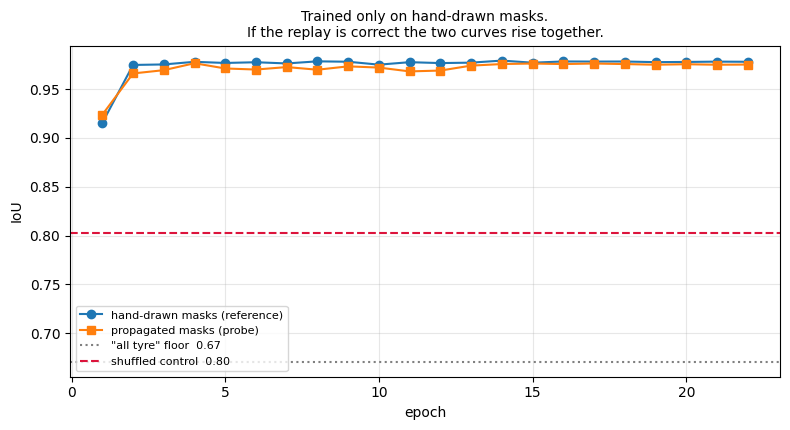

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[HF] pushed 1 file(s)  (part C curves)


True

In [11]:
# === Part C: the verdict ==================================================
iou_clean = evaluate(dl_va)
iou_prop  = evaluate(dl_pr)

# Control: score the same predictions against SHUFFLED propagated masks. This
# is what a broken annotation looks like, in the same units, on the same images.
class Shuffled(Dataset):
    def __init__(self, X, Y):
        self.X, self.Y = X, Y
        self.perm = np.random.RandomState(0).permutation(len(Y))
        while (self.perm == np.arange(len(Y))).any():        # no mask paired with itself
            self.perm = np.random.RandomState(np.random.randint(1e6)).permutation(len(Y))
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = ((self.X[i].astype(np.float32)/255.0) - MEAN)/STD
        y = (self.Y[self.perm[i]] > 0).astype(np.float32)
        return torch.from_numpy(x.transpose(2,0,1)), torch.from_numpy(y)[None]

iou_shuf = evaluate(DataLoader(Shuffled(Xpr, Ypr), batch_size=BS, num_workers=LOADER_WORKERS))

ratio = iou_prop/max(1e-9, iou_clean)
print('=' * 68)
print(f'  val A  hand-drawn masks, held-out tyres     IoU {iou_clean:.4f}   <- reference')
print(f'  val B  propagated masks, same photographs   IoU {iou_prop:.4f}')
print(f'  control  propagated masks, SHUFFLED         IoU {iou_shuf:.4f}   <- broken looks like this')
print(f'  floor    "predict tyre everywhere"          IoU {TRIVIAL:.4f}')
print('=' * 68)
print(f'\n  propagated / hand-drawn = {ratio:.3f}      (want > 0.90)')

C_OK = ratio > 0.90 and iou_prop > iou_shuf + 0.10 and iou_clean > TRIVIAL + 0.05
if C_OK:
    print('\n  PART C: PASS')
    print('  The model was trained only on hand-drawn masks and scores essentially')
    print('  the same against the propagated ones. The replay put them in the right')
    print('  place. The annotations are usable on all 4,598 images.')
else:
    print('\n  PART C: FAIL')
    if iou_clean <= TRIVIAL + 0.05:
        print('  The model barely beats "predict tyre everywhere", so this run says')
        print('  nothing about the annotations. Train longer before concluding.')
    else:
        print('  The model transfers to the hand-drawn masks but not to the propagated')
        print('  ones, on the same photographs. That is the labels, not the model.')
        print('  Re-run scripts/propagate_annotations.py and check its verification.')

RESULTS['part_c'] = {'ok': bool(C_OK), 'iou_clean': iou_clean, 'iou_propagated': iou_prop,
                     'iou_shuffled_control': iou_shuf, 'iou_trivial_floor': TRIVIAL,
                     'ratio': ratio}
save_results('part C complete')

# The two curves, side by side. Tracking together = correct replay.
h = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(h.epoch, h.val_iou_clean, 'o-', label='hand-drawn masks (reference)')
ax.plot(h.epoch, h.val_iou_propagated, 's-', label='propagated masks (probe)')
ax.axhline(TRIVIAL, ls=':', c='grey', label=f'"all tyre" floor  {TRIVIAL:.2f}')
ax.axhline(iou_shuf, ls='--', c='crimson', label=f'shuffled control  {iou_shuf:.2f}')
ax.set_xlabel('epoch'); ax.set_ylabel('IoU'); ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.set_title('Trained only on hand-drawn masks.\nIf the replay is correct the two curves rise together.',
             fontsize=10)
plt.tight_layout()
p = STAGE/'partC_curves.png'; plt.savefig(p, dpi=110, bbox_inches='tight'); plt.show()
PUSH.add(p, 'partC_curves.png'); PUSH.flush('part C curves')


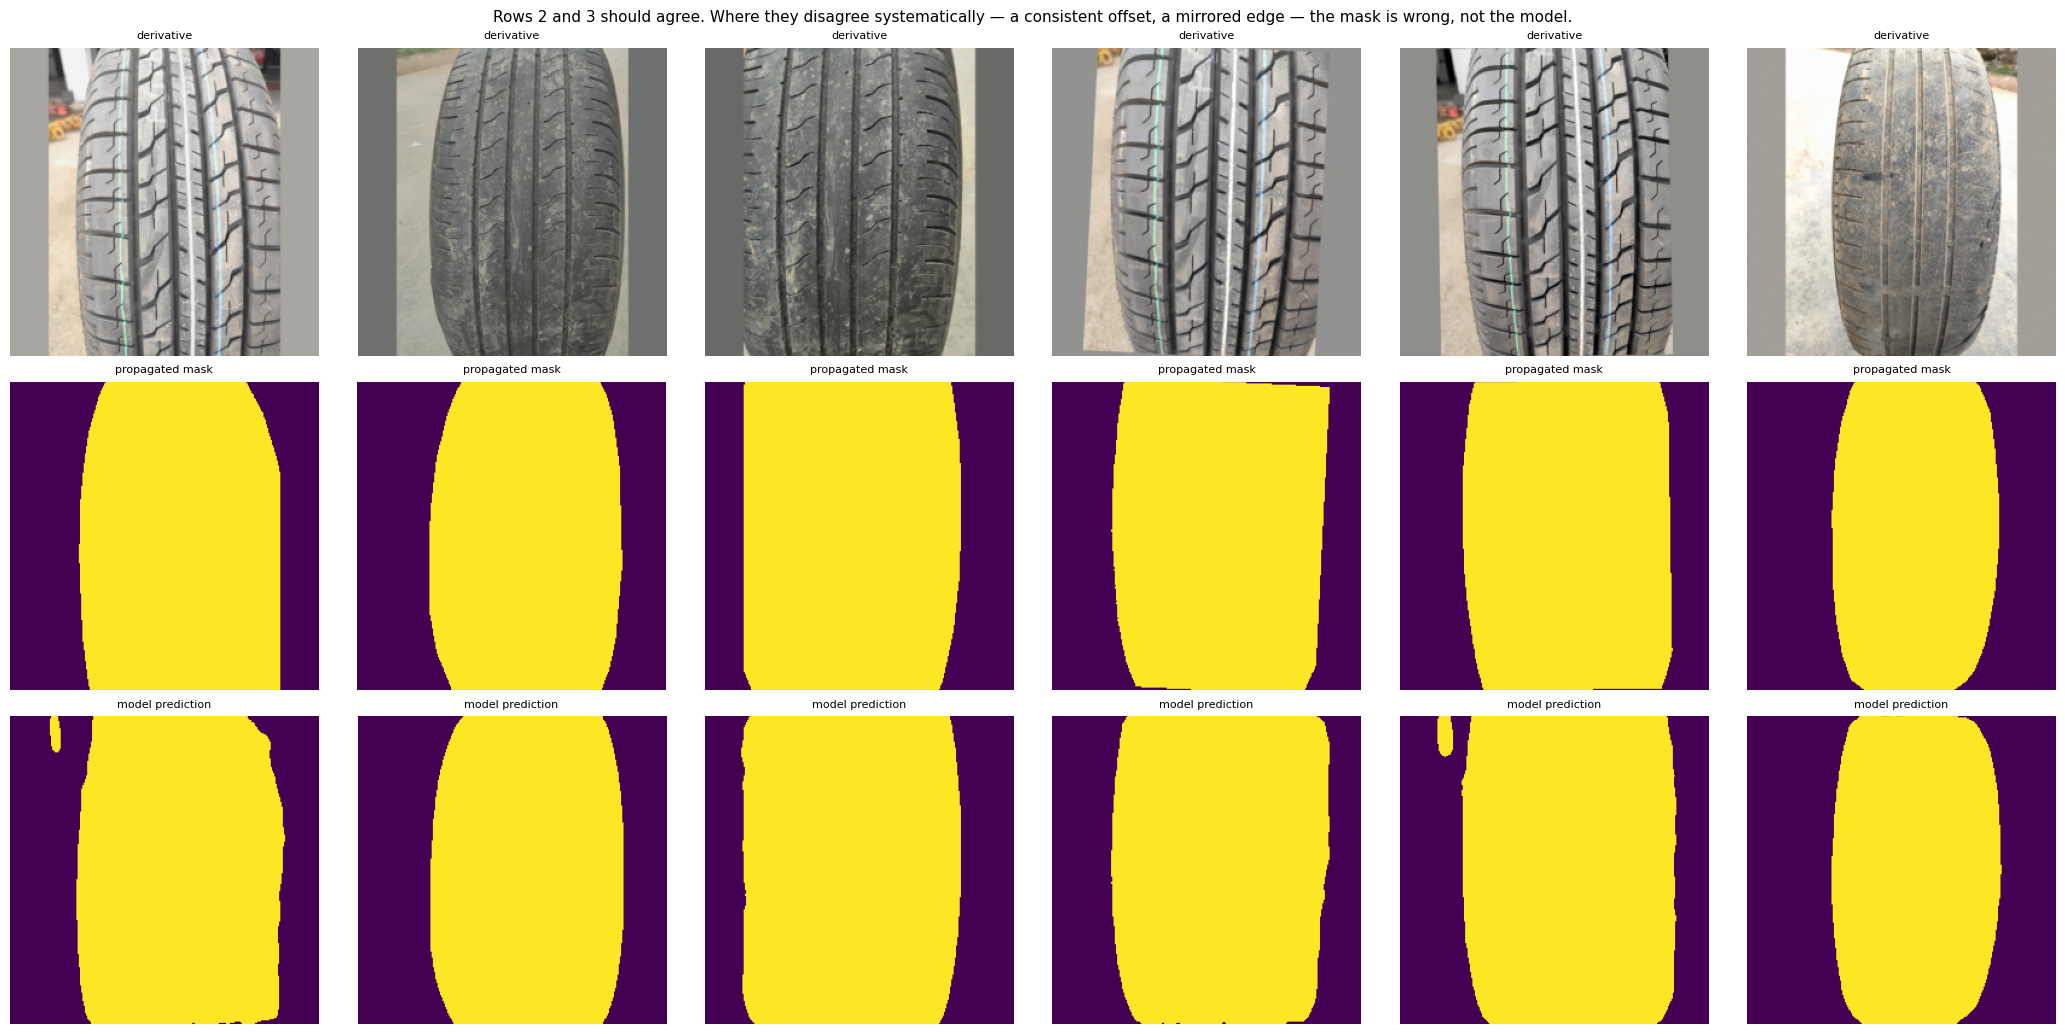

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[HF] pushed 1 file(s)  (part C figures)


True

In [12]:
# === What the model predicts, next to what the annotation says ============
model.eval()
pick = np.random.RandomState(5).choice(len(Xpr), 6, replace=False)
fig, axes = plt.subplots(3, 6, figsize=(21, 10.5))
for j, i in enumerate(pick):
    x = ((Xpr[i].astype(np.float32)/255.0) - MEAN)/STD
    with torch.no_grad(), autocast():
        pr = torch.sigmoid(model(torch.from_numpy(x.transpose(2,0,1))[None].to(dev)))[0,0].float().cpu().numpy()
    axes[0,j].imshow(Xpr[i]);            axes[0,j].set_title('derivative', fontsize=8)
    axes[1,j].imshow(Ypr[i] > 0);        axes[1,j].set_title('propagated mask', fontsize=8)
    axes[2,j].imshow(pr > 0.5);          axes[2,j].set_title('model prediction', fontsize=8)
    for k in range(3): axes[k,j].axis('off')
plt.suptitle('Rows 2 and 3 should agree. Where they disagree systematically — '
             'a consistent offset, a mirrored edge — the mask is wrong, not the model.', fontsize=11)
plt.tight_layout()
p = STAGE/'partC_predictions.png'; plt.savefig(p, dpi=95, bbox_inches='tight'); plt.show()
PUSH.add(p, 'partC_predictions.png'); PUSH.flush('part C figures')


In [13]:
# === Verdict and final push ===============================================
verdict = {'part_a_coverage': RESULTS.get('part_a',{}).get('ok'),
           'part_b_geometry': RESULTS.get('part_b',{}).get('ok'),
           'part_c_differential': RESULTS.get('part_c',{}).get('ok')}
RESULTS['verdict'] = verdict
RESULTS['annotation_version'] = v.get('annotation_version','?')
RESULTS['annotation_fingerprint'] = ANN_FINGERPRINT
RESULTS['notebook_revision'] = NBT1_REVISION
RESULTS['gpu_count'] = GPU_COUNT
RESULTS['config_hash'] = CONFIG_HASH
RESULTS['finished'] = time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime())

print('=' * 68)
for k, val in verdict.items():
    print(f'  {k:26s} {"PASS" if val else "FAIL" if val is False else "not run"}')
print('=' * 68)
all_ok = all(v is True for v in verdict.values())
print('\nThe annotations are usable on all 4,598 images.' if all_ok
      else '\nDo not train the study on these masks until the failing part passes.')

save_results('NBT1 complete')
_fired.set()          # the guards have nothing left to rescue
if PUSH.on:
    from huggingface_hub import HfApi
    files = set(HfApi(token=HF_TOKEN).list_repo_files(HF_REPO, repo_type='dataset'))
    want = [f'{HF_PREFIX}/{n}' for n in ('results.json','history.csv','resume_status.json','partB_overlays.png',
                                         'partC_curves.png','partC_predictions.png','nbt1_unet.pt')]
    print('\non HuggingFace:')
    for w in want: print(f'  {"yes" if w in files else "MISSING"}  {w}')
print(f'\ncommits this session: {PUSH.commits}')
PUSH.close()


  part_a_coverage            PASS
  part_b_geometry            PASS
  part_c_differential        PASS

The annotations are usable on all 4,598 images.
[HF] pushed 1 file(s)  (NBT1 complete)

on HuggingFace:
  yes  annotation_test/2026-08-30-r1/results.json
  yes  annotation_test/2026-08-30-r1/history.csv
  yes  annotation_test/2026-08-30-r1/resume_status.json
  yes  annotation_test/2026-08-30-r1/partB_overlays.png
  yes  annotation_test/2026-08-30-r1/partC_curves.png
  yes  annotation_test/2026-08-30-r1/partC_predictions.png
  yes  annotation_test/2026-08-30-r1/nbt1_unet.pt

commits this session: 9
